In [2]:
# Run before creating models or starting training.
# This replaces the earlier unfinished S0 configuration.
if globals().get("s1_initialized", False):
    raise RuntimeError(
        "S1 has already initialized this run. "
        "Use a fresh runtime before replacing the experiment configuration."
    )

if any(globals().get(name) is not None for name in ("hypernet", "classifier")):
    raise RuntimeError("Models already exist. Do not replace their configuration.")

config = {
    # We are checking whether the complete learning/forgetting process works.
    "experiment_name": "uncle_permuted_mnist_debug",
    "dataset": "Permuted-MNIST",
    "backbone": "resnet18",
    "pretrained": False,

    # Every task recognizes the same ten digits.
    # The difference between tasks is how their pixels are rearranged.
    "task_classes": {
        "A": list(range(10)),
        "B": list(range(10)),
        "C": list(range(10)),
    },
    "permutation_seeds": {
        "A": 101,
        "B": 102,
        "C": 103,
    },
    "requests": [
        ("learn", "A"),
        ("learn", "B"),
        ("forget", "A"),
        ("learn", "C"),
    ],
    "learn_each_task_once": True,

    # Split the original examples BEFORE making task permutations.
    # All tasks reuse these split boundaries to avoid data leakage.
    "split_plan": {
        "train": "90% of official MNIST training examples",
        "validation": "10% of official MNIST training examples",
        "test": "Official MNIST test examples",
    },
    "validation_fraction": 0.10,
    "stratified_split": True,
    "evaluation_split": "validation",
    "seed": 42,
    "split_seed": 42,

    # Development input policy: preserve the original 28 x 28 image size.
    "input_channels": 1,
    "image_size": 28,
    "pixel_scaling": "Convert pixels to floats in [0, 1]",
    "augmentation": "none",
    "resnet_stem": "3x3 convolution, stride 1, padding 1; no initial max-pool",

    # Short initial training run. Five epochs may not be enough to converge.
    "batch_size": 64,
    "epochs": 5,
    "num_workers": 0,
    "optimizer": "Adam",
    "learning_rate": 0.001,
    "scheduler": {"name": "constant"},
    "weight_decay": 0.0,

    # The paper's stated coefficients for Permuted-MNIST.
    "beta": 0.1,
    "gamma": 0.01,

    # Hypernetwork sizes reported in the paper.
    "hidden_widths": [128, 256, 512],
    "task_embedding_dim": 32,
    "chunk_embedding_dim": 32,
    "num_chunks": 200,

    # Our explicit reconstruction choices for weight generation.
    "hidden_activation": "ReLU",
    "embedding_initialization": "Independent standard normal values",
    "chunk_mapping": (
        "Within each output-head group, flatten parameters in a saved order. "
        "Allocate 200 chunks across groups in proportion to parameter count, "
        "with at least one per group. Pad each group's last chunk and discard "
        "padding when reconstructing parameter tensors."
    ),
    "output_head_mapping": {
        "batchnorm": "All BatchNorm affine parameters, including shortcut BatchNorm",
        "shortcut": "Shortcut projection convolution parameters",
        "main": "All remaining convolution and classifier parameters",
    },

    # This is a development approximation, NOT Hyperfan.
    "initialization": {
        "method": "conventional_initialization_with_output_scaling",
        "hidden_layers": "Kaiming normal for ReLU; zero biases",
        "output_heads": "Xavier normal; zero biases",
        "generated_weights": "Scale raw convolution/linear weights by sqrt(2/fan_in)",
        "generated_biases": "Scale raw biases by 0.01",
        "batchnorm_scale": "1 + 0.01 * raw output",
        "batchnorm_shift": "0.01 * raw output",
    },
    "hyperfan_initialization": "Not implemented in this development run",

    # Use the written equations' squared-distance reduction.
    # Do not accidentally replace the parameter sum with an elementwise mean.
    "loss_reduction": {
        "classification": "Mean cross-entropy over the current batch",
        "parameter_distance": "Sum of squared differences over actual parameters",
        "preservation": "Mean parameter distance over protected tasks",
        "noise": "Mean parameter distance over noise samples",
        "padding": "Exclude padded entries from all parameter losses",
        "empty_protected_set": "Zero preservation loss",
    },

    # Keep each task's running image statistics separate.
    "batchnorm_buffer_policy": (
        "Store running mean, variance, and batch counter per task. "
        "Update only while learning that task. Freeze during evaluation "
        "and unlearning."
    ),
    "optimizer_reset_policy": "Create a fresh Adam optimizer for each request",
    "snapshot_refresh_policy": (
        "Copy the current hypernetwork at the start of every request. "
        "Keep that reference fixed until the request finishes."
    ),
    "forgotten_task_protection": (
        "Protect previously forgotten tasks at their current generated weights "
        "during later requests. Exclude the task currently being forgotten."
    ),
    "chunk_embedding_policy": "Train on the first task only; freeze afterward",

    # Noise and forgetting settings.
    "noise_samples": 10,
    "noise_distribution": "standard_normal",
    "fresh_noise_each_update": True,
    "burn_in_start": 100,
    "burn_in_min": 20,
    "burn_in_decay": 0.9,
    "burn_in_rounding": "max(20, floor(100 * 0.9**k))",

    # Evaluation and storage.
    "accuracy_units": "percent",
    "spill_task_set": "All previously seen tasks except the current forget target",
    "output_dir": "/content/drive/MyDrive/uncle_experiment",
}

requests = config["requests"]
s0_ready = False

print("Configured experiment:", config["experiment_name"])
print("Request sequence:", requests)

Configured experiment: uncle_permuted_mnist_debug
Request sequence: [('learn', 'A'), ('learn', 'B'), ('forget', 'A'), ('learn', 'C')]


In [3]:
from IPython.display import Markdown, display

assumptions = [
    {
        "setting": "Model sizes, Adam learning rate, noise settings",
        "source": "Paper",
        "note": "Use the reported values recorded in config.",
    },
    {
        "setting": "Beta and gamma",
        "source": "Paper",
        "note": "Use the stated Permuted-MNIST values: 0.1 and 0.01.",
    },
    {
        "setting": "Three tasks, five epochs, batch size 64",
        "source": "Development choice",
        "note": "A short debugging run, not the full paper experiment.",
    },
    {
        "setting": "Seeds, split, constant learning rate",
        "source": "Development choice",
        "note": "Explicit choices for our first run.",
    },
    {
        "setting": "Small-image ResNet stem and input preprocessing",
        "source": "Reconstruction choice",
        "note": "Use one-channel 28 x 28 images; verify the authors' details later.",
    },
    {
        "setting": "Chunk allocation and output-head mapping",
        "source": "Reconstruction choice",
        "note": "The paper does not fully specify the parameter mapping.",
    },
    {
        "setting": "Initialization",
        "source": "Development deviation",
        "note": "Conventional initialization with output scaling, not Hyperfan.",
    },
    {
        "setting": "Loss reduction",
        "source": "Written paper equations",
        "note": "Sum squared parameter errors; average over tasks or noise samples.",
    },
    {
        "setting": "BatchNorm, optimizer resets, snapshot refresh",
        "source": "Reconstruction choice",
        "note": "Use the explicit policies in config.",
    },
    {
        "setting": "Protect previously forgotten tasks",
        "source": "Reconstruction choice",
        "note": "This may affect relapse and needs a later comparison.",
    },
    {
        "setting": "Burn-in rounding",
        "source": "Reconstruction choice",
        "note": "Round down after decay; never use fewer than 20 updates.",
    },
]

# Show a readable table without introducing a custom class or helper.
table = "| Setting | Source | Note |\n"
table += "| --- | --- | --- |\n"

for record in assumptions:
    table += (
        f"| {record['setting']} | {record['source']} | "
        f"{record['note']} |\n"
    )

display(Markdown(table))

| Setting | Source | Note |
| --- | --- | --- |
| Model sizes, Adam learning rate, noise settings | Paper | Use the reported values recorded in config. |
| Beta and gamma | Paper | Use the stated Permuted-MNIST values: 0.1 and 0.01. |
| Three tasks, five epochs, batch size 64 | Development choice | A short debugging run, not the full paper experiment. |
| Seeds, split, constant learning rate | Development choice | Explicit choices for our first run. |
| Small-image ResNet stem and input preprocessing | Reconstruction choice | Use one-channel 28 x 28 images; verify the authors' details later. |
| Chunk allocation and output-head mapping | Reconstruction choice | The paper does not fully specify the parameter mapping. |
| Initialization | Development deviation | Conventional initialization with output scaling, not Hyperfan. |
| Loss reduction | Written paper equations | Sum squared parameter errors; average over tasks or noise samples. |
| BatchNorm, optimizer resets, snapshot refresh | Reconstruction choice | Use the explicit policies in config. |
| Protect previously forgotten tasks | Reconstruction choice | This may affect relapse and needs a later comparison. |
| Burn-in rounding | Reconstruction choice | Round down after decay; never use fewer than 20 updates. |


In [4]:
from pathlib import PurePosixPath

s0_ready = False
requests = config["requests"]

# Check the main settings for this selected development experiment.
assert config["dataset"] == "Permuted-MNIST"
assert config["batch_size"] > 0
assert config["epochs"] > 0
assert 0 < config["validation_fraction"] < 1
assert PurePosixPath(config["output_dir"]).is_absolute()
assert config["evaluation_split"] == "validation"

# Each task must recognize all ten digits.
for task_id, classes in config["task_classes"].items():
    assert classes == list(range(10)), f"Wrong classes for task {task_id}."
    assert task_id in config["permutation_seeds"]

# Check the request sequence using temporary bookkeeping only.
# This does not create or modify the real training state.
check_seen = set()
check_retained = set()

for action, task_id in requests:
    assert task_id in config["task_classes"], f"Unknown task: {task_id}"

    if action == "learn":
        assert task_id not in check_seen, f"Task {task_id} is learned twice."
        check_seen.add(task_id)
        check_retained.add(task_id)

    elif action == "forget":
        assert task_id in check_retained, f"Task {task_id} is not retained."
        check_retained.remove(task_id)

    else:
        raise ValueError(f"Unknown action: {action}")

assert check_retained == {"B", "C"}

# S1 and S4 still need to check the actual runtime and model memory use.
s0_ready = True

print("S0 configuration checks passed.")
print("Final intended retained tasks: B and C.")
print("Final intended forgotten task: A.")
print("No data downloaded and no model trained.")
print("Next: S1.")

S0 configuration checks passed.
Final intended retained tasks: B and C.
Final intended forgotten task: A.
No data downloaded and no model trained.
Next: S1.


In [5]:
from pathlib import PurePosixPath
import math

# Always clear the flag before checking the current settings.
s0_ready = False
requests = config["requests"]
problems = []

# Every undecided setting must be filled in explicitly.
for setting, value in config.items():
    if value is None:
        problems.append(f"Missing setting: {setting}")

# Check seed ranges accepted by the S1 initialization code.
for setting in ("seed", "split_seed"):
    value = config[setting]

    if value is not None:
        if type(value) is not int or not 0 <= value < 2**32:
            problems.append(f"{setting} must be an integer from 0 to 2**32 - 1.")

# Check basic training settings.
for setting in ("batch_size", "epochs"):
    value = config[setting]

    if value is not None:
        if type(value) is not int or value <= 0:
            problems.append(f"{setting} must be a positive integer.")

for setting in ("beta", "gamma"):
    value = config[setting]

    if value is not None:
        valid_number = type(value) in (int, float)

        if not valid_number or not math.isfinite(value) or value <= 0:
            problems.append(f"{setting} must be a finite positive number.")

# Check the output path without creating any folders.
output_path = config["output_dir"]

if output_path is not None:
    if not isinstance(output_path, str) or not output_path.strip():
        problems.append("output_dir must be a nonempty string.")
    elif not PurePosixPath(output_path).is_absolute():
        problems.append("output_dir must be an absolute Colab path.")

# Check that all three data splits have a written plan.
split_plan = config["split_plan"]

if split_plan is not None:
    if not isinstance(split_plan, dict):
        problems.append("split_plan must be a dictionary.")
    else:
        for split in ("train", "validation", "test"):
            if not split_plan.get(split):
                problems.append(f"Describe the {split} split in split_plan.")

# Check task definitions.
task_classes = config["task_classes"]
valid_tasks = isinstance(task_classes, dict) and bool(task_classes)

if task_classes is not None:
    if not valid_tasks:
        problems.append("task_classes must be a nonempty dictionary.")
    else:
        for task_id, classes in task_classes.items():
            if not isinstance(classes, list) or len(classes) != 10:
                problems.append(f"Task {task_id} must list exactly 10 class IDs.")

# Check request order without changing the real experiment state.
if requests is not None:
    if not isinstance(requests, list) or not requests:
        problems.append("requests must be a nonempty list.")
    elif valid_tasks:
        learned_ids = set()
        retained_ids = set()

        for index, request in enumerate(requests):
            if not isinstance(request, (tuple, list)) or len(request) != 2:
                problems.append(f"Request {index} must contain an action and task ID.")
                continue

            action, task_id = request

            # Task IDs must be simple identifiers that can be dictionary keys.
            if type(task_id) not in (int, str):
                problems.append(f"Request {index} has an invalid task ID.")
                continue

            if task_id not in task_classes:
                problems.append(f"Request {index} refers to an undefined task.")
                continue

            if action == "learn":
                if task_id in learned_ids:
                    problems.append(f"Task {task_id} is learned more than once.")
                else:
                    learned_ids.add(task_id)
                    retained_ids.add(task_id)

            elif action == "forget":
                if task_id not in retained_ids:
                    problems.append(f"Task {task_id} cannot be forgotten at request {index}.")
                else:
                    retained_ids.remove(task_id)

            else:
                problems.append(f"Request {index} must use 'learn' or 'forget'.")

if problems:
    print("S0 is not ready:")
    for problem in problems:
        print(f"  - {problem}")

    raise ValueError("Fill or correct the settings above, then rerun the S0 table and check.")

s0_ready = True
print("S0 configuration checks passed. Next: S1.")

S0 configuration checks passed. Next: S1.


In [6]:
import os
import sys
import random
import tempfile
from pathlib import Path

import numpy as np
import psutil
import torch

# S0 must finish successfully before we initialize the experiment.
if not globals().get("s0_ready", False):
    raise RuntimeError("Run the S0 configuration and check cells first.")

if "config" not in globals() or not isinstance(config, dict):
    raise RuntimeError("The config dictionary from S0 is missing.")

seed = config.get("seed")
output_path = config.get("output_dir")

if type(seed) is not int or not 0 <= seed < 2**32:
    raise ValueError("config['seed'] must be an integer from 0 to 2**32 - 1.")

if not isinstance(output_path, str) or not output_path.strip():
    raise ValueError("config['output_dir'] must contain a folder path.")

output_dir = Path(output_path).expanduser()

if not output_dir.is_absolute():
    raise ValueError("Use an absolute output path.")

# These are measured values, not assumptions about the Colab machine.
gib = 1024**3
memory = psutil.virtual_memory()

runtime_report = {
    "Python version": sys.version.split()[0],
    "PyTorch version": str(torch.__version__),
    "PyTorch CUDA version": torch.version.cuda,
    "CUDA available": torch.cuda.is_available(),
    "Logical CPU cores": psutil.cpu_count(logical=True),
    "Physical CPU cores": psutil.cpu_count(logical=False),
    "System RAM total (GiB)": round(memory.total / gib, 2),
    "System RAM available (GiB)": round(memory.available / gib, 2),
}

if torch.cuda.is_available():
    gpu_index = torch.cuda.current_device()
    free_vram, total_vram = torch.cuda.mem_get_info(gpu_index)

    runtime_report["GPU name"] = torch.cuda.get_device_name(gpu_index)
    runtime_report["GPU VRAM free (GiB)"] = round(free_vram / gib, 2)
    runtime_report["GPU VRAM total (GiB)"] = round(total_vram / gib, 2)

for name, value in runtime_report.items():
    print(f"{name}: {value}")

if not torch.cuda.is_available():
    raise RuntimeError(
        "No GPU is available. Select a GPU in Colab's runtime settings."
    )

print(f"\nOutput folder: {output_dir}")

Python version: 3.13.15
PyTorch version: 2.11.0+cu128
PyTorch CUDA version: 12.8
CUDA available: True
Logical CPU cores: 12
Physical CPU cores: 6
System RAM total (GiB): 83.47
System RAM available (GiB): 81.4
GPU name: NVIDIA A100-SXM4-40GB
GPU VRAM free (GiB): 39.08
GPU VRAM total (GiB): 39.49

Output folder: /content/drive/MyDrive/uncle_experiment


In [7]:
drive_root = Path("/content/drive")
uses_drive = output_dir == drive_root or drive_root in output_dir.parents

if uses_drive:
    # Reuse an existing mount instead of forcing a remount.
    if not os.path.ismount(str(drive_root)):
        from google.colab import drive

        drive.mount(str(drive_root))

    if not os.path.ismount(str(drive_root)):
        raise RuntimeError("Google Drive did not mount successfully.")

    print("Google Drive is mounted.")
else:
    print("The configured output path does not require Google Drive.")
    print("Runtime-local files may disappear when the Colab session ends.")

Mounted at /content/drive
Google Drive is mounted.


In [8]:
# Prevent accidental seed resets.
if globals().get("s1_initialized", False):
    raise RuntimeError(
        "S1 is already initialized. Run the check cell or continue to S2."
    )

existing_models = [
    name
    for name in ("hypernet", "classifier")
    if globals().get(name) is not None
]

if existing_models:
    raise RuntimeError(
        f"Models already exist: {existing_models}. "
        "Do not reset seeds during an existing experiment."
    )

# Create the output folder without deleting existing files.
output_dir.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda", gpu_index)

# Seed each library that may generate random numbers.
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

# Reduce variation in convolution behavior between repeated runs.
# These settings do not guarantee identical results across all machines.
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

s1_initialized = True
s1_checks_passed = False

print(f"Device: {device}")
print(f"Seed: {seed}")
print(f"Output folder: {output_dir}")
print("Initialization complete. Run the check cell next.")

Device: cuda:0
Seed: 42
Output folder: /content/drive/MyDrive/uncle_experiment
Initialization complete. Run the check cell next.


In [9]:
if not globals().get("s1_initialized", False):
    raise RuntimeError("Run the S1 initialization cell first.")

s1_checks_passed = False

# Shape: one vector with four numbers, stored on the GPU.
check_values = torch.tensor([1.0, 2.0, 3.0, 4.0], device=device)

# Expected result: 1 + 4 + 9 + 16 = 30.
check_result = check_values.square().sum().item()

if check_result != 30.0:
    raise RuntimeError(f"Unexpected GPU calculation result: {check_result}")

del check_values

# Create a uniquely named temporary file in the output folder.
# Close and reopen it to check that saved contents can be read.
check_text = "UnCLe S1 storage check"

with tempfile.TemporaryDirectory(
    prefix="s1_check_",
    dir=str(output_dir),
) as check_directory:
    check_file = Path(check_directory) / "storage_check.txt"
    check_file.write_text(check_text, encoding="utf-8")
    recovered_text = check_file.read_text(encoding="utf-8")

    if recovered_text != check_text:
        raise RuntimeError("The storage check returned unexpected contents.")

# The temporary check directory and its file are now removed.
s1_checks_passed = True

print("PASS: GPU calculation returned 30.")
print("PASS: Output folder supports saving and reading a file.")
print("S1 checks passed. Next: S2.")

PASS: GPU calculation returned 30.
PASS: Output folder supports saving and reading a file.
S1 checks passed. Next: S2.


In [10]:
import json
from pathlib import Path

import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

if not globals().get("s1_checks_passed", False):
    raise RuntimeError("Complete S1 and its check cell first.")

if globals().get("s2_initialized", False):
    raise RuntimeError(
        "S2 is already initialized. Reuse its variables instead of rebuilding."
    )

if config["dataset"] != "Permuted-MNIST":
    raise ValueError("These cells implement the selected Permuted-MNIST experiment.")

if config["num_workers"] != 0:
    raise ValueError("This first version expects num_workers = 0.")

if any(globals().get(name) is not None for name in ("hypernet", "classifier")):
    raise RuntimeError("Do not rebuild task definitions after creating models.")

s2_checks_passed = False

# Cache the original download on the Colab runtime.
# Split definitions will be saved separately to your persistent output folder.
data_dir = Path("/content/uncle_data")

# MNIST stores compact original images once.
# ToTensor converts an individual image to [1, 28, 28] floats in [0, 1].
base_train = datasets.MNIST(
    root=str(data_dir),
    train=True,
    download=True,
    transform=transforms.ToTensor(),
)

base_test = datasets.MNIST(
    root=str(data_dir),
    train=False,
    download=True,
    transform=transforms.ToTensor(),
)

print("Official training examples:", len(base_train))
print("Official test examples:", len(base_test))

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.49MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 129kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.23MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.25MB/s]

Official training examples: 60000
Official test examples: 10000


In [11]:
# A separate random generator avoids changing the model's training randomness.
split_rng = np.random.default_rng(config["split_seed"])

official_train_labels = base_train.targets.numpy()
train_parts = []
validation_parts = []

# Hold out approximately 10% within each digit class.
# Whole-example rounding can make the total fraction slightly different.
for digit in range(10):
    digit_indices = np.flatnonzero(official_train_labels == digit)
    shuffled_indices = split_rng.permutation(digit_indices)

    validation_count = round(
        len(digit_indices) * config["validation_fraction"]
    )

    if not 0 < validation_count < len(digit_indices):
        raise ValueError(f"Invalid validation count for digit {digit}.")

    validation_parts.append(shuffled_indices[:validation_count])
    train_parts.append(shuffled_indices[validation_count:])

# Sorting makes definitions easier to compare and save.
# The training loader will shuffle the training examples later.
train_indices = np.sort(np.concatenate(train_parts))
validation_indices = np.sort(np.concatenate(validation_parts))
test_indices = np.arange(len(base_test), dtype=np.int64)

task_specs = {}

for task_id, classes in config["task_classes"].items():
    if classes != list(range(10)):
        raise ValueError(f"Task {task_id} must contain digits 0 through 9.")

    permutation_seed = config["permutation_seeds"][task_id]
    permutation_rng = np.random.default_rng(permutation_seed)

    # Shape: [784]. Every pixel position appears exactly once.
    pixel_permutation = torch.from_numpy(
        permutation_rng.permutation(28 * 28).astype(np.int64)
    )

    task_specs[task_id] = {
        "classes": list(classes),
        "class_to_local": {
            original_label: local_label
            for local_label, original_label in enumerate(classes)
        },
        "permutation_seed": permutation_seed,
        "pixel_permutation": pixel_permutation,

        # These arrays are shared references, not copies per task.
        "train_indices": train_indices,
        "validation_indices": validation_indices,
        "test_indices": test_indices,
    }

print("Training split:", len(train_indices))
print("Validation split:", len(validation_indices))
print("Test split:", len(test_indices))
print("Tasks:", list(task_specs))

Training split: 54001
Validation split: 5999
Test split: 10000
Tasks: ['A', 'B', 'C']


In [12]:
split_metadata = {
    "dataset": config["dataset"],
    "split_seed": config["split_seed"],
    "validation_fraction": config["validation_fraction"],
    "validation_rounding": "round separately within each digit class",
    "permutation_seeds": config["permutation_seeds"],
    "task_classes": config["task_classes"],
    "train_source": "MNIST official training set",
    "validation_source": "MNIST official training set",
    "test_source": "MNIST official test set",
}

split_arrays = {
    "train_indices": train_indices,
    "validation_indices": validation_indices,
    "test_indices": test_indices,
    "metadata": np.array(json.dumps(split_metadata, sort_keys=True)),
}

for task_id, specification in task_specs.items():
    split_arrays[f"permutation_{task_id}"] = (
        specification["pixel_permutation"].numpy()
    )

split_file = output_dir / "permuted_mnist_split_definitions.npz"

if split_file.exists():
    # Refuse to silently replace definitions from a different experiment.
    with np.load(split_file, allow_pickle=False) as saved:
        if set(saved.files) != set(split_arrays):
            raise RuntimeError("Saved split definitions have different fields.")

        for name, values in split_arrays.items():
            if not np.array_equal(saved[name], values):
                raise RuntimeError(
                    f"Saved definition differs: {name}. "
                    "Use a separate output folder for a changed experiment."
                )

    print("Existing saved definitions match.")
else:
    # Exclusive creation prevents overwriting an existing file.
    with split_file.open("xb") as file:
        np.savez_compressed(file, **split_arrays)

    print("Saved definitions:", split_file)

Saved definitions: /content/drive/MyDrive/uncle_experiment/permuted_mnist_split_definitions.npz


In [13]:
class PermutedMNISTTask(Dataset):
    """Read one image, rearrange its pixels, and return its local digit label."""

    def __init__(self, base_dataset, indices, permutation, class_to_local):
        self.base_dataset = base_dataset
        self.indices = indices
        self.permutation = permutation
        self.class_to_local = class_to_local

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, position):
        original_index = int(self.indices[position])
        image, original_label = self.base_dataset[original_index]

        # Flatten [1, 28, 28] to [784], rearrange, then restore the image shape.
        image = image.reshape(-1)[self.permutation].reshape(1, 28, 28)
        local_label = self.class_to_local[int(original_label)]

        return image, local_label


# These wrappers share the original image storage.
# No task-specific image collection is precomputed.
task_datasets = {}

for task_id, specification in task_specs.items():
    task_datasets[task_id] = {}

    for split_name in ("train", "validation", "test"):
        original_dataset = base_test if split_name == "test" else base_train

        task_datasets[task_id][split_name] = PermutedMNISTTask(
            base_dataset=original_dataset,
            indices=specification[f"{split_name}_indices"],
            permutation=specification["pixel_permutation"],
            class_to_local=specification["class_to_local"],
        )

# Prepare only the first requested task's training loader.
# S5 will later manage request execution; this does not advance its index.
if requests[0][0] != "learn":
    raise ValueError("The first request must be a learning request.")

current_train_task_id = requests[0][1]

# A separate generator controls training-data order.
train_loader_generator = torch.Generator()
train_loader_generator.manual_seed(config["seed"])

train_loader = DataLoader(
    task_datasets[current_train_task_id]["train"],
    batch_size=config["batch_size"],
    shuffle=True,
    num_workers=0,
    generator=train_loader_generator,
    pin_memory=(device.type == "cuda"),
    drop_last=False,
)

s2_initialized = True

print("Created training loader for task:", current_train_task_id)
print("No training loaders were created for the other tasks.")

Created training loader for task: A
No training loaders were created for the other tasks.


train class counts: [5331, 6068, 5362, 5518, 5258, 4879, 5326, 5639, 5266, 5354]
validation class counts: [592, 674, 596, 613, 584, 542, 592, 626, 585, 595]
test class counts: [980, 1135, 1032, 1010, 982, 892, 958, 1028, 974, 1009]
Batch image shape: (64, 1, 28, 28)
Batch label shape: (64,)


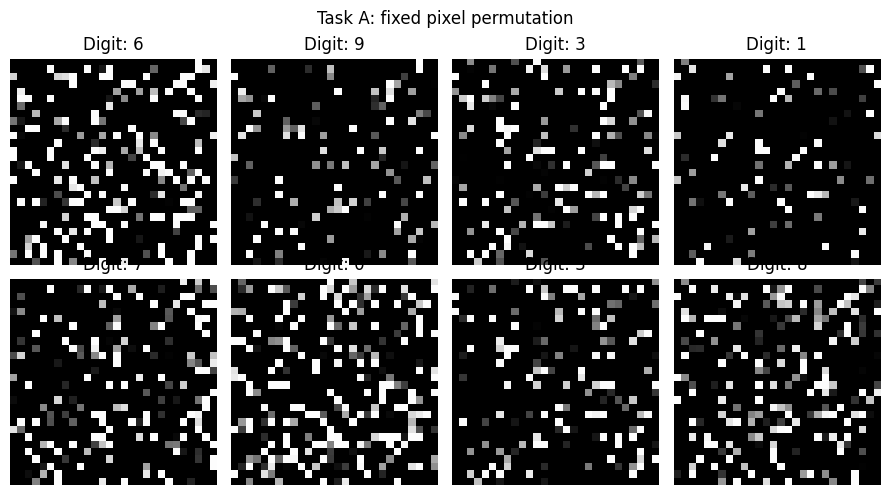

S2 checks passed. Next: S3.


In [14]:
if not globals().get("s2_initialized", False):
    raise RuntimeError("Run the preceding S2 cells first.")

s2_checks_passed = False

# Training and validation must partition the official training examples.
assert np.intersect1d(train_indices, validation_indices).size == 0

combined_indices = np.concatenate([train_indices, validation_indices])
assert np.array_equal(
    np.sort(combined_indices),
    np.arange(len(base_train)),
)

assert np.array_equal(test_indices, np.arange(len(base_test)))

# Check class counts in every split.
split_labels = {
    "train": base_train.targets[torch.from_numpy(train_indices)],
    "validation": base_train.targets[torch.from_numpy(validation_indices)],
    "test": base_test.targets,
}

for split_name, labels in split_labels.items():
    counts = torch.bincount(labels, minlength=10)
    assert counts.shape == (10,)
    assert torch.all(counts > 0)
    print(f"{split_name} class counts:", counts.tolist())

# Check permutation validity and actual output tensors.
task_ids = list(task_specs)

for task_id in task_ids:
    permutation = task_specs[task_id]["pixel_permutation"]
    assert torch.equal(torch.sort(permutation).values, torch.arange(784))

    for split_name in ("train", "validation", "test"):
        image, label = task_datasets[task_id][split_name][0]

        assert image.shape == (1, 28, 28)
        assert image.dtype == torch.float32
        assert torch.isfinite(image).all()
        assert 0.0 <= image.min().item() <= image.max().item() <= 1.0
        assert 0 <= label <= 9

# Confirm the selected tasks have different pixel arrangements.
for first_index, first_task in enumerate(task_ids):
    for second_task in task_ids[first_index + 1:]:
        assert not torch.equal(
            task_specs[first_task]["pixel_permutation"],
            task_specs[second_task]["pixel_permutation"],
        )

# Read a real batch, then restore loader randomness so this preview
# does not alter the order of examples used by later training.
loader_rng_state = train_loader_generator.get_state()

try:
    preview_images, preview_labels = next(iter(train_loader))
finally:
    train_loader_generator.set_state(loader_rng_state)

assert preview_images.shape[1:] == (1, 28, 28)
assert preview_labels.dtype == torch.int64
assert preview_labels.min().item() >= 0
assert preview_labels.max().item() <= 9

print("Batch image shape:", tuple(preview_images.shape))
print("Batch label shape:", tuple(preview_labels.shape))

figure, axes = plt.subplots(2, 4, figsize=(9, 5))

for index, axis in enumerate(axes.flat):
    axis.imshow(preview_images[index, 0], cmap="gray", vmin=0, vmax=1)
    axis.set_title(f"Digit: {preview_labels[index].item()}")
    axis.axis("off")

figure.suptitle(f"Task {current_train_task_id}: fixed pixel permutation")
plt.tight_layout()
plt.show()

s2_checks_passed = True
print("S2 checks passed. Next: S3.")

In [15]:
import math
import torch
from torch import nn
from torch.func import functional_call
from torchvision.models import resnet18

if not globals().get("s2_checks_passed", False):
    raise RuntimeError("Complete the S2 check first.")

if "hypernet" in globals() or "classifier" in globals():
    raise RuntimeError("S3 models already exist. Do not initialize them again.")

if config["initialization"]["method"] != "conventional_initialization_with_output_scaling":
    raise ValueError("These cells implement the development initialization from S0.")

classifier = resnet18(weights=None, num_classes=10)
classifier.conv1 = nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1, bias=False)
classifier.maxpool = nn.Identity()
classifier = classifier.to(device)

# Train generated weights through the hypernetwork, not these template weights.
classifier.requires_grad_(False)

task_embeddings = {}
task_status = {}
task_buffers = {}

# BatchNorm statistics are separate from trainable weights.
# L1 will clone these starting statistics for each new task.
buffer_template = {
    name: value.detach().clone()
    for name, value in classifier.named_buffers()
}

In [16]:
groups = {"main": [], "shortcut": [], "batchnorm": []}
group_sizes = {group: 0 for group in groups}
parameter_map = {}
modules = dict(classifier.named_modules())

for name, parameter in classifier.named_parameters():
    module_name, parameter_name = name.rsplit(".", 1)
    is_batchnorm = isinstance(modules[module_name], nn.BatchNorm2d)

    if is_batchnorm:
        group = "batchnorm"
    elif "downsample" in module_name:
        group = "shortcut"
    else:
        group = "main"

    # S0's development scaling: small biases and BatchNorm scales near one.
    scale, offset = 0.01, 0.0
    if is_batchnorm and parameter_name == "weight":
        offset = 1.0
    elif not is_batchnorm and parameter_name == "weight":
        fan_in = math.prod(parameter.shape[1:])
        scale = math.sqrt(2 / fan_in)

    start = group_sizes[group]
    stop = start + parameter.numel()

    parameter_map[name] = {
        "group": group, "start": start, "stop": stop,
        "shape": tuple(parameter.shape), "scale": scale, "offset": offset,
    }
    groups[group].append(name)
    group_sizes[group] = stop

In [17]:
total_weights = sum(group_sizes.values())
remaining = config["num_chunks"] - len(groups)

# Give each group one chunk, then divide the remaining chunks proportionally.
shares = {
    group: remaining * size / total_weights
    for group, size in group_sizes.items()
}
chunk_counts = {
    group: 1 + math.floor(shares[group])
    for group in groups
}

# Assign rounding leftovers to the groups with the largest fractional shares.
leftover = config["num_chunks"] - sum(chunk_counts.values())
rounding_order = sorted(
    groups, key=lambda group: shares[group] % 1, reverse=True
)
for group in rounding_order[:leftover]:
    chunk_counts[group] += 1

chunk_widths = {
    group: math.ceil(group_sizes[group] / chunk_counts[group])
    for group in groups
}

for group in groups:
    print(group, ":", chunk_counts[group], "chunks of", chunk_widths[group], "numbers")

main : 195 chunks of 56366 numbers
shortcut : 4 chunks of 43008 numbers
batchnorm : 1 chunks of 9600 numbers


In [18]:
input_width = config["task_embedding_dim"] + config["chunk_embedding_dim"]
widths = [input_width] + config["hidden_widths"]

layers = []
for input_size, output_size in zip(widths[:-1], widths[1:]):
    layers.append(nn.Linear(input_size, output_size))
    layers.append(nn.ReLU())

hypernet = nn.ModuleDict({
    "shared": nn.Sequential(*layers),
    "heads": nn.ModuleDict({
        group: nn.Linear(widths[-1], chunk_widths[group])
        for group in groups
    }),
}).to(device)

chunk_embeddings = nn.Parameter(torch.randn(
    config["num_chunks"],
    config["chunk_embedding_dim"],
    device=device,
))

# L1 will enable these for the first task only.
# L4 will freeze them after that task finishes.
chunk_embeddings.requires_grad_(False)

Parameter containing:
tensor([[ 0.1940,  2.1614, -0.1721,  ..., -1.1835, -1.8029, -1.5808],
        [ 0.8387,  1.4192,  0.6469,  ..., -0.8146,  0.2502, -0.4273],
        [ 1.1044, -1.1028,  0.5543,  ..., -0.6463,  0.0749,  0.1939],
        ...,
        [-0.9932, -0.8017,  1.9661,  ..., -0.6168,  0.6920,  0.3391],
        [ 0.5063,  0.5746,  0.7750,  ...,  0.2995, -1.3159, -1.2063],
        [-0.4656,  1.7651, -0.1238,  ..., -0.1481,  1.5505, -0.3742]],
       device='cuda:0')

In [19]:
for layer in hypernet["shared"]:
    if isinstance(layer, nn.Linear):
        nn.init.kaiming_normal_(layer.weight, nonlinearity="relu")
        nn.init.zeros_(layer.bias)

for head in hypernet["heads"].values():
    nn.init.xavier_normal_(head.weight)
    nn.init.zeros_(head.bias)

hypernet_count = sum(parameter.numel() for parameter in hypernet.parameters())
chunk_count = chunk_embeddings.numel()

# Float32 uses four bytes per number.
# Hypernetwork: weights, gradients, two Adam states, and one reference copy.
estimated_bytes = 4 * (
    5 * hypernet_count + 3 * total_weights + 4 * chunk_count
)

print(f"Classifier parameters: {total_weights:,}")
print(f"Hypernetwork parameters: {hypernet_count:,}")
print(f"Chunk-code parameters: {chunk_count:,}")
print(f"Approximate core training storage: {estimated_bytes / 1024**3:.2f} GiB")
print("Initialization: development approximation, not Hyperfan.")

Classifier parameters: 11,172,810
Hypernetwork parameters: 56,076,590
Chunk-code parameters: 6,400
Approximate core training storage: 1.17 GiB
Initialization: development approximation, not Hyperfan.


In [20]:
def generate_weights(task_code, network, chunk_codes):
    """Turn one task code into a dictionary of classifier weights."""
    generated_groups = {}
    first_chunk = 0

    for group in groups:
        count = chunk_counts[group]
        codes = chunk_codes[first_chunk:first_chunk + count]

        # Repeat the task code once per chunk, then join the two codes.
        repeated_task = task_code.unsqueeze(0).expand(count, -1)
        inputs = torch.cat([repeated_task, codes], dim=1)

        features = network["shared"](inputs)
        raw_weights = network["heads"][group](features).reshape(-1)

        # Remove padding from the final chunk.
        generated_groups[group] = raw_weights[:group_sizes[group]]
        first_chunk += count

    weights = {}
    for name, entry in parameter_map.items():
        values = generated_groups[entry["group"]]
        values = values[entry["start"]:entry["stop"]]
        values = values.reshape(entry["shape"])
        weights[name] = values * entry["scale"] + entry["offset"]

    return weights

In [21]:
s3_checks_passed = False

check_code = torch.zeros(config["task_embedding_dim"], device=device)
check_weights = generate_weights(check_code, hypernet, chunk_embeddings)

expected_parameters = dict(classifier.named_parameters())
assert set(check_weights) == set(expected_parameters)
assert sum(chunk_counts.values()) == config["num_chunks"]

for name, weight in check_weights.items():
    assert weight.shape == expected_parameters[name].shape
    assert weight.requires_grad
    assert torch.isfinite(weight).all()

check_buffers = {
    name: value.clone() for name, value in buffer_template.items()
}

previous_mode = classifier.training
classifier.eval()

try:
    with torch.no_grad():
        check_images = torch.zeros(2, 1, 28, 28, device=device)
        check_scores = functional_call(
            classifier, (check_weights, check_buffers),
            (check_images,), strict=True,
        )

    assert check_scores.shape == (2, 10)
    assert torch.isfinite(check_scores).all()
finally:
    classifier.train(previous_mode)

del check_weights, check_buffers, check_images, check_scores, check_code

s3_checks_passed = True
print("S3 checks passed: every weight matches, and two images produce 2 x 10 scores.")

S3 checks passed: every weight matches, and two images produce 2 x 10 scores.


In [22]:
import copy
import gc
import torch
import torch.nn.functional as F

if not globals().get("s3_checks_passed", False):
    raise RuntimeError("Complete the S3 check first.")

s4_checks_passed = False
s4_report = {}

probe_batch_size = 4
probe_task_id = requests[0][1]

# Keep this small batch on the CPU until the check starts.
probe_samples = [
    task_datasets[probe_task_id]["train"][index]
    for index in range(probe_batch_size)
]
probe_images = torch.stack([image for image, label in probe_samples])
probe_labels = torch.tensor(
    [label for image, label in probe_samples], dtype=torch.long
)

print("Image shape:", tuple(probe_images.shape))  # [4, 1, 28, 28]
print("Labels:", probe_labels.tolist())

Image shape: (4, 1, 28, 28)
Labels: [5, 0, 4, 1]


In [23]:
probe = {}

torch.cuda.synchronize(device)
torch.cuda.reset_peak_memory_stats(device)
baseline_bytes = torch.cuda.memory_allocated(device)

with torch.random.fork_rng(devices=[device.index]):
    try:
        # Copy the models. Only these copies will receive updates.
        probe["hypernet"] = copy.deepcopy(hypernet)
        probe["classifier"] = copy.deepcopy(classifier).train()

        # Simulate a new first task, with trainable task and chunk codes.
        probe["task_code"] = torch.nn.Parameter(
            torch.randn(config["task_embedding_dim"], device=device)
        )
        probe["chunks"] = torch.nn.Parameter(
            chunk_embeddings.detach().clone()
        )
        probe["buffers"] = {
            name: value.clone() for name, value in buffer_template.items()
        }

        probe["optimizer"] = torch.optim.Adam(
            list(probe["hypernet"].parameters())
            + [probe["task_code"], probe["chunks"]],
            lr=config["learning_rate"],
            weight_decay=config["weight_decay"],
        )

        # Generate the copied classifier's weights without detaching them.
        probe["weights"] = generate_weights(
            probe["task_code"], probe["hypernet"], probe["chunks"]
        )
        assert all(weight.requires_grad for weight in probe["weights"].values())

        probe["scores"] = functional_call(
            probe["classifier"],
            (probe["weights"], probe["buffers"]),
            (probe_images.to(device),),
            strict=True,
        )
        assert probe["scores"].shape == (probe_batch_size, 10)

        # Cross-entropy measures how far the digit predictions are from the labels.
        probe["loss"] = F.cross_entropy(
            probe["scores"], probe_labels.to(device)
        )
        assert torch.isfinite(probe["loss"]).item(), "Loss is not finite."

        probe["optimizer"].zero_grad(set_to_none=True)
        probe["loss"].backward()

        # Every hypernetwork parameter should receive a finite gradient.
        assert all(
            parameter.grad is not None
            and torch.isfinite(parameter.grad).all().item()
            for parameter in probe["hypernet"].parameters()
        ), "Some hypernetwork gradients are missing or nonfinite."

        gradient_size = sum(
            parameter.grad.norm().item()
            for parameter in probe["hypernet"].parameters()
        )
        assert gradient_size > 0, "All hypernetwork gradients are zero."

        # Track a parameter that actually received a nonzero gradient.
        probe["tracked"] = next(
            parameter for parameter in probe["hypernet"].parameters()
            if parameter.grad.norm().item() > 0
        )
        probe["before"] = probe["tracked"].detach().clone()

        probe["optimizer"].step()

        parameter_changed = not torch.equal(
            probe["before"], probe["tracked"].detach()
        )
        assert parameter_changed, "The optimizer did not change the parameter."

        torch.cuda.synchronize(device)
        s4_report = {
            "Batch size": probe_batch_size,
            "Prediction loss": probe["loss"].item(),
            "Sum of gradient norms": gradient_size,
            "Parameter changed": parameter_changed,
            "GPU baseline (GiB)": baseline_bytes / 1024**3,
            "GPU peak allocated (GiB)": (
                torch.cuda.max_memory_allocated(device) / 1024**3
            ),
        }

    finally:
        # Release copies, optimizer state, generated weights, and their graphs.
        probe.clear()
        gc.collect()

In [24]:
if not s4_report:
    raise RuntimeError("The disposable learning check did not complete.")

for name, value in s4_report.items():
    print(f"{name}: {value}")

print(
    "GPU allocated after cleanup (GiB):",
    round(torch.cuda.memory_allocated(device) / 1024**3, 3),
)

del probe_samples, probe_images, probe_labels, probe

s4_checks_passed = True
print("\nS4 passed. The real experiment has not been trained.")
print("Next: S5.")

Batch size: 4
Prediction loss: 2.343789577484131
Sum of gradient norms: 66.84598482586443
Parameter changed: True
GPU baseline (GiB): 0.2602553367614746
GPU peak allocated (GiB): 1.3983073234558105
GPU allocated after cleanup (GiB): 0.269

S4 passed. The real experiment has not been trained.
Next: S5.


In [25]:
import time

if not globals().get("s4_checks_passed", False):
    raise RuntimeError("Complete the S4 check first.")


def evaluate_tasks(task_ids, split):
    """Return each task's accuracy as a percentage without training."""
    accuracies = {}
    previous_classifier_mode = classifier.training
    previous_hypernet_mode = hypernet.training

    classifier.eval()
    hypernet.eval()

    try:
        with torch.no_grad():
            for task_id in task_ids:
                weights = generate_weights(
                    task_embeddings[task_id], hypernet, chunk_embeddings
                )

                # Copies protect the stored statistics from accidental changes.
                buffers = {
                    name: value.detach().clone()
                    for name, value in task_buffers[task_id].items()
                }

                evaluation_generator = torch.Generator()
                evaluation_generator.manual_seed(config["seed"])

                loader = DataLoader(
                    task_datasets[task_id][split],
                    batch_size=config["batch_size"],
                    shuffle=False,
                    num_workers=0,
                    generator=evaluation_generator,
                )

                correct = 0
                total = 0

                for images, labels in loader:
                    images = images.to(device)
                    labels = labels.to(device)

                    scores = functional_call(
                        classifier, (weights, buffers), (images,), strict=True
                    )
                    if not torch.isfinite(scores).all().item():
                        raise RuntimeError(f"Nonfinite predictions for task {task_id}.")

                    predictions = scores.argmax(dim=1)
                    correct += (predictions == labels).sum().item()
                    total += labels.numel()

                if total == 0:
                    raise RuntimeError(f"No evaluation examples for task {task_id}.")

                accuracies[task_id] = 100.0 * correct / total
                del weights, buffers, scores, images, labels, predictions

    finally:
        classifier.train(previous_classifier_mode)
        hypernet.train(previous_hypernet_mode)

    return accuracies

In [26]:
# Initialize bookkeeping once. Never reset existing progress.
if "history" not in globals():
    history = []

if "next_request_index" not in globals():
    if history:
        raise RuntimeError("History exists but the request index is missing. Restore C1.")
    next_request_index = 0

if "pending_request" not in globals():
    pending_request = None

if pending_request is not None:
    raise RuntimeError("A request is already pending. Finish it through E1 and C1.")

if not 0 <= next_request_index <= len(requests):
    raise RuntimeError("The saved request index is invalid.")

requests_finished = next_request_index == len(requests)

if requests_finished:
    print("All requests are complete. Continue to R1.")
else:
    action, target_task_id = requests[next_request_index]

    if target_task_id not in task_specs:
        raise ValueError(f"Unknown task: {target_task_id}")

    if action == "learn":
        if target_task_id in task_status or target_task_id in task_embeddings:
            raise RuntimeError(f"Task {target_task_id} has already been introduced.")
    elif action == "forget":
        if task_status.get(target_task_id) != "retained":
            raise RuntimeError(f"Task {target_task_id} is not currently retained.")
    else:
        raise ValueError(f"Unknown action: {action}")

    print(f"Next request: {action} task {target_task_id}")

Next request: learn task A


In [27]:
if not requests_finished:
    # Also guard this cell against being run twice.
    if pending_request is not None:
        raise RuntimeError("This request has already been opened.")

    request_eval_split = config["evaluation_split"]
    if request_eval_split not in ("validation", "test"):
        raise ValueError("evaluation_split must be 'validation' or 'test'.")

    seen_task_ids = list(task_status)

    for task_id in seen_task_ids:
        if task_status[task_id] not in ("retained", "forgotten"):
            raise RuntimeError(f"Task {task_id} has an unfinished status.")
        if task_id not in task_embeddings or task_id not in task_buffers:
            raise RuntimeError(f"Task {task_id} is missing its code or statistics.")

    # Forgotten tasks are included so we can detect later recovery.
    before_accuracy = evaluate_tasks(seen_task_ids, request_eval_split)

    torch.cuda.synchronize(device)
    torch.cuda.reset_peak_memory_stats(device)
    request_start_memory = torch.cuda.memory_allocated(device)
    request_start_time = time.perf_counter()

    current_request = {
        "index": next_request_index,
        "action": action,
        "task_id": target_task_id,
        "evaluation_split": request_eval_split,
        "phase": "prepared",
    }
    pending_request = current_request

    print("Before-request accuracy (%):", before_accuracy)
    print("Request prepared. No training or forgetting has happened.")

Before-request accuracy (%): {}
Request prepared. No training or forgetting has happened.


In [28]:
if requests_finished:
    print("Next: R1.")
else:
    assert pending_request is current_request
    assert current_request["index"] == next_request_index
    assert set(before_accuracy) == set(task_status)
    assert all(0.0 <= value <= 100.0 for value in before_accuracy.values())

    if not before_accuracy:
        print("No previous tasks to evaluate. This is expected for the first request.")

    print("S5 checks passed.")
    print("Next:", "L1" if current_request["action"] == "learn" else "U1")

No previous tasks to evaluate. This is expected for the first request.
S5 checks passed.
Next: L1


In [29]:
import copy
import torch
from torch import nn
from torch.utils.data import DataLoader

if globals().get("pending_request") is None:
    raise RuntimeError("Run S5 to prepare a request first.")

if current_request["action"] != "learn":
    raise RuntimeError("This is a forget request. Continue to U1 instead.")

if current_request["phase"] != "prepared":
    raise RuntimeError("This request has already started setup or training.")

current_task_id = current_request["task_id"]

if current_task_id in task_embeddings:
    raise RuntimeError("This task already has an embedding. Do not replace it.")

# This implementation follows the policies selected in S0.
if config["optimizer"] != "Adam" or config["scheduler"] != {"name": "constant"}:
    raise ValueError("These cells expect Adam with a constant learning rate.")

if config["optimizer_reset_policy"] != "Create a fresh Adam optimizer for each request":
    raise ValueError("The configured optimizer policy needs a different implementation.")

expected_protection = (
    "Protect previously forgotten tasks at their current generated weights "
    "during later requests. Exclude the task currently being forgotten."
)
if config["forgotten_task_protection"] != expected_protection:
    raise ValueError("The configured protection policy needs a different implementation.")

print("Preparing to learn task:", current_task_id)

Preparing to learn task: A


In [30]:
if current_request["phase"] != "prepared":
    raise RuntimeError("Task setup has already started. Do not rerun this cell.")

# Mark setup as started before changing any experiment state.
current_request["phase"] = "learning_setup"

is_first_task = len(task_embeddings) == 0
protected_task_ids = list(task_status)

for embedding in task_embeddings.values():
    embedding.requires_grad_(False)

# Save the reference before learning this task.
reference_hypernet = copy.deepcopy(hypernet).eval()
reference_hypernet.requires_grad_(False)
reference_chunk_embeddings = chunk_embeddings.detach().clone()

# Create the new task's trainable code.
task_embeddings[current_task_id] = nn.Parameter(
    torch.randn(config["task_embedding_dim"], device=device)
)

hypernet.requires_grad_(True)
chunk_embeddings.requires_grad_(is_first_task)

# Each task starts with its own independent BatchNorm statistics.
task_buffers[current_task_id] = {
    name: value.clone() for name, value in buffer_template.items()
}

current_request["phase"] = "learning_state_created"

print("Protected tasks:", protected_task_ids)
print("Train chunk embeddings:", is_first_task)

Protected tasks: []
Train chunk embeddings: True


In [31]:
if current_request["phase"] != "learning_state_created":
    raise RuntimeError("Run the preceding setup cell once before this cell.")

current_request["phase"] = "learning_optimizer_setup"

trainable_parameters = list(hypernet.parameters())
trainable_parameters.append(task_embeddings[current_task_id])

if is_first_task:
    trainable_parameters.append(chunk_embeddings)

optimizer = torch.optim.Adam(
    trainable_parameters,
    lr=config["learning_rate"],
    weight_decay=config["weight_decay"],
)

# The selected schedule keeps the learning rate unchanged.
scheduler = None

train_loader_generator = torch.Generator()
train_loader_generator.manual_seed(config["seed"] + current_request["index"])

train_loader = DataLoader(
    task_datasets[current_task_id]["train"],
    batch_size=config["batch_size"],
    shuffle=True,
    num_workers=config["num_workers"],
    generator=train_loader_generator,
    pin_memory=(device.type == "cuda"),
    drop_last=False,
)

current_train_task_id = current_task_id
current_request["phase"] = "learning_ready"

In [32]:
assert current_request["phase"] == "learning_ready"
assert current_task_id not in protected_task_ids
assert set(protected_task_ids) == set(task_status)

assert all(not p.requires_grad for p in reference_hypernet.parameters())
assert not reference_chunk_embeddings.requires_grad
assert task_embeddings[current_task_id].requires_grad
assert chunk_embeddings.requires_grad == is_first_task

for task_id in protected_task_ids:
    assert not task_embeddings[task_id].requires_grad

expected_ids = {id(parameter) for parameter in trainable_parameters}
optimizer_ids = {
    id(parameter)
    for group in optimizer.param_groups
    for parameter in group["params"]
}
assert optimizer_ids == expected_ids

reference_ids = {id(parameter) for parameter in reference_hypernet.parameters()}
assert optimizer_ids.isdisjoint(reference_ids)
assert all(parameter.requires_grad for parameter in trainable_parameters)

trainable_count = sum(parameter.numel() for parameter in trainable_parameters)

print(f"Trainable parameters: {trainable_count:,}")
print("Protected tasks:", protected_task_ids)
print("L1 checks passed. No training step has been taken.")
print("Next: L2.")

Trainable parameters: 56,083,022
Protected tasks: []
L1 checks passed. No training step has been taken.
Next: L2.


In [33]:
import copy
import torch
import torch.nn.functional as F

if globals().get("current_request", {}).get("phase") != "learning_ready":
    raise RuntimeError("Complete L1 before running this preview.")

preview_dataset = task_datasets[current_task_id]["train"]
preview_count = min(config["batch_size"], len(preview_dataset))

# The existing MNIST transforms are deterministic.
preview_samples = [preview_dataset[index] for index in range(preview_count)]

preview_images = torch.stack([image for image, label in preview_samples])
preview_labels = torch.tensor(
    [label for image, label in preview_samples], dtype=torch.long
)

print("Task:", current_task_id)
print("Image batch:", tuple(preview_images.shape))
print("Label range:", preview_labels.min().item(), "to", preview_labels.max().item())

Task: A
Image batch: (64, 1, 28, 28)
Label range: 0 to 9


In [34]:
preview = {}
l2_report = {}

# Restore PyTorch randomness afterward, even if the preview fails.
with torch.random.fork_rng(devices=[device.index]):
    try:
        preview["classifier"] = copy.deepcopy(classifier).train()
        preview["buffers"] = {
            name: value.detach().clone()
            for name, value in task_buffers[current_task_id].items()
        }

        # No gradient graph is needed for this read-only preview.
        with torch.no_grad():
            preview["weights"] = generate_weights(
                task_embeddings[current_task_id],
                hypernet,
                chunk_embeddings,
            )

            # Output shape: [number of images, 10].
            preview["scores"] = functional_call(
                preview["classifier"],
                (preview["weights"], preview["buffers"]),
                (preview_images.to(device),),
                strict=True,
            )

            preview["loss"] = F.cross_entropy(
                preview["scores"], preview_labels.to(device)
            )

            # Save small results, not model copies or computation graphs.
            l2_report = {
                "image_shape": tuple(preview_images.shape),
                "prediction_shape": tuple(preview["scores"].shape),
                "scores_finite": torch.isfinite(preview["scores"]).all().item(),
                "loss": preview["loss"].item(),
            }

    finally:
        # Release the disposable classifier, buffers, weights, and outputs.
        preview.clear()

In [35]:
import math

assert l2_report, "The preview did not finish."
assert l2_report["prediction_shape"] == (preview_count, 10)
assert l2_report["scores_finite"], "Some prediction scores are not finite."
assert math.isfinite(l2_report["loss"]), "The loss is not finite."
assert preview_labels.min().item() >= 0
assert preview_labels.max().item() <= 9

print("Prediction shape:", l2_report["prediction_shape"])
print("Cross-entropy loss:", l2_report["loss"])
print("L2 checks passed. No optimizer step was taken.")

del preview_samples, preview_images, preview_labels, preview_dataset, preview

print("Next: L3.")

Prediction shape: (64, 10)
Cross-entropy loss: 2.306384801864624
L2 checks passed. No optimizer step was taken.
Next: L3.


In [36]:
import copy
import torch
import torch.nn.functional as F

if globals().get("current_request", {}).get("phase") != "learning_ready":
    raise RuntimeError("Complete L1 before defining the learning update.")

# These cells implement the sum-over-weights reduction selected in S0.
if config["loss_reduction"]["parameter_distance"] != (
    "Sum of squared differences over actual parameters"
):
    raise ValueError("The parameter-loss reduction differs from this implementation.")

learning_state = {
    "network": hypernet,
    "classifier": classifier,
    "chunks": chunk_embeddings,
    "embeddings": task_embeddings,
    "buffers": task_buffers,
    "optimizer": optimizer,
    "reference": reference_hypernet,
    "reference_chunks": reference_chunk_embeddings,
    "task_id": current_task_id,
    "protected_ids": list(protected_task_ids),
    "beta": config["beta"],
}

In [37]:
def learn_one_batch(images, labels, state):
    """Learn from one batch while preserving the selected earlier tasks."""
    network = state["network"]
    image_model = state["classifier"]
    task_id = state["task_id"]
    batch_optimizer = state["optimizer"]

    network.train()
    image_model.train()
    batch_optimizer.zero_grad(set_to_none=True)

    # Part 1: predict the current batch using freshly generated weights.
    weights = generate_weights(
        state["embeddings"][task_id], network, state["chunks"]
    )
    scores = functional_call(
        image_model,
        (weights, state["buffers"][task_id]),
        (images.to(device),),
        strict=True,
    )
    prediction_error = F.cross_entropy(scores, labels.to(device))

    if not torch.isfinite(prediction_error).item():
        raise RuntimeError("The prediction error is not finite.")

    prediction_value = prediction_error.item()
    prediction_error.backward()

    # Release this graph before processing earlier tasks.
    del weights, scores, prediction_error

    # Part 2: preserve earlier tasks. An empty list gives zero error.
    preservation_value = 0.0
    protected_count = len(state["protected_ids"])

    for earlier_task in state["protected_ids"]:
        fixed_code = state["embeddings"][earlier_task].detach()

        with torch.no_grad():
            target = generate_weights(
                fixed_code, state["reference"], state["reference_chunks"]
            )

        current = generate_weights(fixed_code, network, state["chunks"])

        # Sum over actual weights, then average over protected tasks.
        distance = sum(
            (current[name] - target[name]).square().sum()
            for name in current
        )
        preservation_error = distance / protected_count

        if not torch.isfinite(preservation_error).item():
            raise RuntimeError("The preservation error is not finite.")

        preservation_value += preservation_error.item()
        (state["beta"] * preservation_error).backward()

        del target, current, distance, preservation_error

    # Reject invalid gradients before changing any parameters.
    for group in batch_optimizer.param_groups:
        for parameter in group["params"]:
            if parameter.grad is not None:
                if not torch.isfinite(parameter.grad).all().item():
                    raise RuntimeError("A training gradient is not finite.")

    batch_optimizer.step()

    # Return numbers only, so logging does not retain computation graphs.
    return {
        "prediction_loss": prediction_value,
        "preservation_loss": preservation_value,
        "total_loss": prediction_value + state["beta"] * preservation_value,
    }

In [38]:
l3_checks_passed = False
l3_report = {}

with torch.random.fork_rng(devices=[device.index]):
    probe_state = copy.deepcopy(learning_state)

    try:
        live_ids = {
            id(parameter)
            for group in optimizer.param_groups
            for parameter in group["params"]
        }
        copied_ids = {
            id(parameter)
            for group in probe_state["optimizer"].param_groups
            for parameter in group["params"]
        }
        assert live_ids.isdisjoint(copied_ids)

        samples = [
            task_datasets[current_task_id]["train"][index]
            for index in range(4)
        ]
        images = torch.stack([image for image, label in samples])
        labels = torch.tensor([label for image, label in samples])

        l3_report = learn_one_batch(images, labels, probe_state)

        # At least one copied hypernetwork parameter must have changed.
        assert any(
            not torch.equal(parameter, hypernet.get_parameter(name))
            for name, parameter in probe_state["network"].named_parameters()
        )

        # Earlier task codes must still match their untouched originals.
        for task_id in protected_task_ids:
            assert torch.equal(
                probe_state["embeddings"][task_id], task_embeddings[task_id]
            )

        # The copied reference must remain frozen and unchanged.
        for name, parameter in probe_state["reference"].named_parameters():
            assert not parameter.requires_grad
            assert parameter.grad is None
            assert torch.equal(parameter, reference_hypernet.get_parameter(name))

        l3_checks_passed = True

    finally:
        # Release copied models, optimizer state, and gradient tensors.
        probe_state.clear()
        # The loop variable may still reference one copied parameter.
        if "parameter" in locals():
            del parameter

In [39]:
assert l3_checks_passed, "The disposable update check did not pass."

for name, value in l3_report.items():
    print(f"{name}: {value:.6f}")

if not protected_task_ids:
    assert l3_report["preservation_loss"] == 0.0
    print("No earlier tasks to preserve, as expected.")

print("L3 passed. Only disposable copies received an optimizer step.")
print("Next: L4.")

prediction_loss: 2.343790
preservation_loss: 0.000000
total_loss: 2.343790
No earlier tasks to preserve, as expected.
L3 passed. Only disposable copies received an optimizer step.
Next: L4.


In [40]:
import time

if not globals().get("l3_checks_passed", False):
    raise RuntimeError("Complete the L3 check first.")

if current_request["phase"] != "learning_ready":
    raise RuntimeError("This request has already started or completed training.")

assert pending_request is current_request
assert current_request["action"] == "learn"
assert current_request["task_id"] == current_train_task_id
assert learning_state["task_id"] == current_train_task_id
assert learning_state["optimizer"] is optimizer

if config["scheduler"] != {"name": "constant"} or scheduler is not None:
    raise ValueError("This loop expects the constant learning rate chosen in S0.")

batches_per_epoch = len(train_loader)
assert batches_per_epoch > 0, "The training loader is empty."

print("Training task:", current_train_task_id)
print("Epochs:", config["epochs"])
print("Batches per epoch:", batches_per_epoch)
print("Learning rate:", optimizer.param_groups[0]["lr"])

Training task: A
Epochs: 5
Batches per epoch: 844
Learning rate: 0.001


In [41]:
if current_request["phase"] != "learning_ready":
    raise RuntimeError("Do not rerun this training cell for the same request.")

current_request["phase"] = "learning_in_progress"
learning_log = []
learning_update_count = 0

try:
    for epoch in range(config["epochs"]):
        torch.cuda.synchronize(device)
        epoch_start = time.perf_counter()

        loss_sums = {
            "prediction_loss": 0.0,
            "preservation_loss": 0.0,
            "total_loss": 0.0,
        }
        examples_seen = 0

        for images, labels in train_loader:
            losses = learn_one_batch(images, labels, learning_state)
            learning_update_count += 1

            batch_size = labels.size(0)
            examples_seen += batch_size

            for name in loss_sums:
                loss_sums[name] += losses[name] * batch_size

        torch.cuda.synchronize(device)

        epoch_result = {
            "epoch": epoch + 1,
            "seconds": time.perf_counter() - epoch_start,
            "examples": examples_seen,
        }
        for name in loss_sums:
            epoch_result[name] = loss_sums[name] / examples_seen

        learning_log.append(epoch_result)

        print(
            f"Epoch {epoch + 1}/{config['epochs']} | "
            f"prediction: {epoch_result['prediction_loss']:.4f} | "
            f"preservation: {epoch_result['preservation_loss']:.4f} | "
            f"total: {epoch_result['total_loss']:.4f} | "
            f"time: {epoch_result['seconds']:.1f}s"
        )

    current_request["phase"] = "learning_updates_finished"

except BaseException:
    # Also catches a manual notebook interruption.
    # Partial training must not be mistaken for a completed request.
    current_request["phase"] = "failed"
    raise

Epoch 1/5 | prediction: 0.5164 | preservation: 0.0000 | total: 0.5164 | time: 27.3s
Epoch 2/5 | prediction: 0.1550 | preservation: 0.0000 | total: 0.1550 | time: 26.7s
Epoch 3/5 | prediction: 0.1067 | preservation: 0.0000 | total: 0.1067 | time: 26.9s
Epoch 4/5 | prediction: 0.0814 | preservation: 0.0000 | total: 0.0814 | time: 26.8s
Epoch 5/5 | prediction: 0.0659 | preservation: 0.0000 | total: 0.0659 | time: 26.8s


In [42]:
if current_request["phase"] != "learning_updates_finished":
    raise RuntimeError("Training must finish successfully before this cell.")

expected_updates = config["epochs"] * batches_per_epoch
assert learning_update_count == expected_updates

optimizer.zero_grad(set_to_none=True)

task_embeddings[current_train_task_id].requires_grad_(False)
chunk_embeddings.requires_grad_(False)
task_status[current_train_task_id] = "retained"

# Keep results available for E1 and the checkpoint in C1.
current_request["learning_log"] = learning_log
current_request["optimizer_updates"] = learning_update_count

learning_state.clear()
del learning_state, reference_hypernet, reference_chunk_embeddings
del train_loader, images, labels

current_request["phase"] = "updates_complete"

print("Training finished. Temporary loader and reference released.")

Training finished. Temporary loader and reference released.


In [43]:
assert current_request["phase"] == "updates_complete"
assert task_status[current_request["task_id"]] == "retained"
assert not task_embeddings[current_request["task_id"]].requires_grad
assert not chunk_embeddings.requires_grad

# The request remains pending until evaluation and saving are complete.
assert pending_request is current_request
assert next_request_index == current_request["index"]

print("Optimizer updates:", learning_update_count)
print("Task status:", task_status)
print("L4 checks passed. Next: E1, then C1.")

Optimizer updates: 4220
Task status: {'A': 'retained'}
L4 checks passed. Next: E1, then C1.


In [46]:
import time
import psutil

if current_request["phase"] != "updates_complete":
    raise RuntimeError("E1 requires a completed learning or forgetting operation.")

if any(record["index"] == current_request["index"] for record in history):
    raise RuntimeError("This request already has an evaluation record.")

evaluation_split = current_request["evaluation_split"]

torch.cuda.synchronize(device)
evaluation_start = time.perf_counter()

after_accuracy = evaluate_tasks(list(task_status), evaluation_split)

torch.cuda.synchronize(device)
evaluation_seconds = time.perf_counter() - evaluation_start

for task_id, accuracy in after_accuracy.items():
    print(f"Task {task_id} {evaluation_split} accuracy: {accuracy:.2f}%")

Task A validation accuracy: 94.65%


In [47]:
if current_request["phase"] != "updates_complete":
    raise RuntimeError("This request has already been recorded.")

if any(record["index"] == current_request["index"] for record in history):
    raise RuntimeError("Duplicate evaluation record prevented.")

spill = None
post_forget_accuracy = None

if current_request["action"] == "forget":
    target = current_request["task_id"]

    # S0's policy measures changes across all other previously seen tasks.
    spill = sum(
        abs(after_accuracy[task_id] - before_accuracy[task_id])
        for task_id in before_accuracy
        if task_id != target
    )
    post_forget_accuracy = after_accuracy[target]

record = {
    "index": current_request["index"],
    "action": current_request["action"],
    "task_id": current_request["task_id"],
    "evaluation_split": evaluation_split,
    "before_accuracy": dict(before_accuracy),
    "after_accuracy": dict(after_accuracy),
    "task_status": dict(task_status),
    "spill": spill,
    "post_forget_accuracy": post_forget_accuracy,
    "learning_log": current_request.get("learning_log", []),
    "optimizer_updates": current_request.get("optimizer_updates"),
    "evaluation_seconds": evaluation_seconds,
    "gpu_peak_allocated_gib": torch.cuda.max_memory_allocated(device) / 1024**3,
    "system_ram_used_gib": psutil.virtual_memory().used / 1024**3,
}

history.append(record)
current_request["phase"] = "evaluated"

print("Evaluation recorded. The request index has not advanced.")

Evaluation recorded. The request index has not advanced.


In [48]:
assert current_request["phase"] == "evaluated"
assert history[-1]["index"] == next_request_index
assert set(after_accuracy) == set(task_status)
assert all(0 <= accuracy <= 100 for accuracy in after_accuracy.values())

print("E1 checks passed.")
print("Next: C1, to save task A before starting task B.")

E1 checks passed.
Next: C1, to save task A before starting task B.


In [49]:
import copy
import os
import random
import tempfile
from pathlib import Path

if current_request["phase"] != "evaluated":
    raise RuntimeError("Complete E1 before saving this request.")

assert history[-1]["index"] == current_request["index"]
assert next_request_index == current_request["index"]

# Convert NumPy arrays to tensors so the checkpoint can use restricted loading.
saved_task_specs = {}
for task_id, specification in task_specs.items():
    saved_task_specs[task_id] = {
        name: torch.from_numpy(value) if isinstance(value, np.ndarray) else value
        for name, value in specification.items()
    }

numpy_state = np.random.get_state()

checkpoint = {
    "format_version": 1,
    "config": copy.deepcopy(config),
    "assumptions": copy.deepcopy(assumptions),
    "requests": copy.deepcopy(requests),
    "next_request_index": next_request_index + 1,
    "history": copy.deepcopy(history),
    "task_status": dict(task_status),
    "completed_forget_count": sum(
        status == "forgotten" for status in task_status.values()
    ),
    "task_specs": saved_task_specs,
    "parameter_map": parameter_map,
    "chunk_counts": chunk_counts,
    "chunk_widths": chunk_widths,

    # Store tensors on the CPU so loading does not require immediate GPU space.
    "hypernet": {
        name: value.detach().cpu()
        for name, value in hypernet.state_dict().items()
    },
    "classifier": {
        name: value.detach().cpu()
        for name, value in classifier.state_dict().items()
    },
    "chunk_embeddings": chunk_embeddings.detach().cpu(),
    "task_embeddings": {
        task_id: value.detach().cpu()
        for task_id, value in task_embeddings.items()
    },
    "task_buffers": {
        task_id: {name: value.detach().cpu() for name, value in buffers.items()}
        for task_id, buffers in task_buffers.items()
    },

    "python_rng": random.getstate(),
    "numpy_rng": {
        "algorithm": numpy_state[0],
        "keys": torch.from_numpy(numpy_state[1].astype(np.int64)),
        "position": numpy_state[2],
        "has_gaussian": numpy_state[3],
        "cached_gaussian": numpy_state[4],
    },
    "torch_rng": torch.get_rng_state(),
    "cuda_rng": torch.cuda.get_rng_state_all(),
}

print("Prepared checkpoint for request:", current_request["index"])

Prepared checkpoint for request: 0


In [50]:
checkpoint_path = output_dir / f"request_{current_request['index']:03d}.pt"

if checkpoint_path.exists():
    raise RuntimeError(
        f"{checkpoint_path.name} already exists. "
        "Do not overwrite it or advance the index manually."
    )

with tempfile.NamedTemporaryFile(
    dir=output_dir, prefix="checkpoint_", suffix=".tmp", delete=False
) as temporary_file:
    temporary_checkpoint_path = Path(temporary_file.name)

try:
    torch.save(checkpoint, temporary_checkpoint_path)
except BaseException:
    temporary_checkpoint_path.unlink(missing_ok=True)
    raise

checkpoint_verified = False
print("Saved temporary checkpoint. Verify it next.")

Saved temporary checkpoint. Verify it next.


In [51]:
loaded = torch.load(
    temporary_checkpoint_path,
    map_location="cpu",
    weights_only=True,
)

verification = {}

with torch.random.fork_rng(devices=[device.index]):
    try:
        verification["network"] = copy.deepcopy(hypernet).eval()
        verification["network"].load_state_dict(loaded["hypernet"])

        verification["classifier"] = copy.deepcopy(classifier).eval()
        verification["classifier"].load_state_dict(loaded["classifier"])

        with torch.no_grad():
            for task_id in task_status:
                image, _ = task_datasets[task_id]["validation"][0]
                image = image.unsqueeze(0).to(device)

                live_weights = generate_weights(
                    task_embeddings[task_id], hypernet, chunk_embeddings
                )
                saved_weights = generate_weights(
                    loaded["task_embeddings"][task_id].to(device),
                    verification["network"],
                    loaded["chunk_embeddings"].to(device),
                )

                live_buffers = {
                    name: value.clone()
                    for name, value in task_buffers[task_id].items()
                }
                saved_buffers = {
                    name: value.to(device)
                    for name, value in loaded["task_buffers"][task_id].items()
                }

                live_scores = functional_call(
                    verification["classifier"],
                    (live_weights, live_buffers), (image,), strict=True,
                )
                saved_scores = functional_call(
                    verification["classifier"],
                    (saved_weights, saved_buffers), (image,), strict=True,
                )

                torch.testing.assert_close(
                    saved_scores, live_scores, rtol=1e-5, atol=1e-6
                )
                print(f"Task {task_id}: saved predictions match.")

                del live_weights, saved_weights, live_buffers, saved_buffers

        checkpoint_verified = True

    finally:
        verification.clear()

Task A: saved predictions match.


In [52]:
if current_request["phase"] != "evaluated":
    raise RuntimeError("This request has already been saved.")

if not checkpoint_verified:
    raise RuntimeError("The checkpoint must pass verification first.")

assert loaded["next_request_index"] == next_request_index + 1

# Promote the verified temporary file to the completed checkpoint.
os.replace(temporary_checkpoint_path, checkpoint_path)

next_request_index = loaded["next_request_index"]
completed_forget_count = loaded["completed_forget_count"]

current_request["phase"] = "saved"
pending_request = None

del checkpoint, loaded, verification, saved_task_specs

print("Saved:", checkpoint_path)
print("Next request index:", next_request_index)
print("C1 complete. Return to S5.")

Saved: /content/drive/MyDrive/uncle_experiment/request_000.pt
Next request index: 1
C1 complete. Return to S5.


In [ ]:
import subprocess
import sys
from pathlib import Path

if globals().get("pending_request") is None:
    raise RuntimeError("Run S5 to prepare a request first.")

if current_request["action"] != "forget":
    raise RuntimeError("This is a learning request. Continue to L1 instead.")

if current_request["phase"] != "prepared":
    raise RuntimeError("This request has already started setup or forgetting.")

current_task_id = current_request["task_id"]

if task_status.get(current_task_id) != "retained":
    raise RuntimeError(f"Task {current_task_id} is not currently retained.")

if current_task_id not in task_embeddings:
    raise RuntimeError(f"Task {current_task_id} has no embedding to forget.")

# The forgetting objective lives in the uncle package, so this notebook and the
# standalone runner cannot drift apart. Fetch it if this runtime lacks it.
try:
    from uncle import Config as PackageConfig, UnCLe
except ImportError:
    repository = Path("/content/hypernetworks")
    if not repository.exists():
        subprocess.run(
            ["git", "clone", "--depth", "1",
             "https://github.com/sumitasthana/hypernetworks", str(repository)],
            check=True,
        )
    sys.path.insert(0, str(repository))
    from uncle import Config as PackageConfig, UnCLe

print("Preparing to forget task:", current_task_id)

In [ ]:
import copy
import math

import torch
from torch import nn

if current_request["phase"] != "prepared":
    raise RuntimeError("Setup has already started. Do not rerun this cell.")

current_request["phase"] = "forget_setup"


class NotebookHyperNetwork(nn.Module):
    """Shows this notebook's hypernetwork through the interface UnCLe expects.

    It holds the live objects rather than copies, so optimizing it optimizes
    this notebook's own model. The only real difference between the two is
    shape: the package keeps one output head, this notebook keeps one per
    parameter group.
    """

    def __init__(self, network, chunk_codes, task_codes):
        super().__init__()
        self.network = network
        self.chunk_codes = chunk_codes
        # A plain dict on purpose. Task codes are frozen once their own
        # learning request finishes, and forgetting must not re-enable them.
        self.task_codes = task_codes

    def _raw_groups(self, code):
        """The unscaled output of each head, exactly as generate_weights does it."""
        generated = {}
        first_chunk = 0

        for group in groups:
            count = chunk_counts[group]
            codes = self.chunk_codes[first_chunk:first_chunk + count]
            inputs = torch.cat([code.unsqueeze(0).expand(count, -1), codes], dim=1)

            features = self.network["shared"](inputs)
            raw = self.network["heads"][group](features).reshape(-1)

            generated[group] = raw[:group_sizes[group]]
            first_chunk += count

        return generated

    def raw_from_code(self, code):
        """Every generated number before scaling, as one flat vector."""
        return torch.cat([self._raw_groups(code)[group] for group in groups])

    def weights_from_code(self, code):
        generated = self._raw_groups(code)
        weights = {}

        for name, entry in parameter_map.items():
            values = generated[entry["group"]][entry["start"]:entry["stop"]]
            weights[name] = (
                values.reshape(entry["shape"]) * entry["scale"] + entry["offset"]
            )

        return weights

    def raw_for(self, task_id):
        return self.raw_from_code(self.task_codes[task_id])

    def weights_for(self, task_id):
        return self.weights_from_code(self.task_codes[task_id])

    def generator_parameters(self):
        """What forgetting is allowed to change: phi in the paper."""
        return list(self.network.parameters())

    def snapshot(self):
        frozen = NotebookHyperNetwork(
            copy.deepcopy(self.network),
            self.chunk_codes.detach().clone(),
            self.task_codes,
        )
        return frozen.eval().requires_grad_(False)


# S0's policy shortens the burn-in by 10% after each forget, with a floor.
burn_in = max(
    config["burn_in_min"],
    math.floor(
        config["burn_in_start"] * config["burn_in_decay"] ** completed_forget_count
    ),
)

forget_config = PackageConfig(
    tasks=tuple(config["task_classes"]),
    requests=tuple(tuple(request) for request in config["requests"]),
    beta=config["beta"],
    gamma=config["gamma"],
    noise_samples=config["noise_samples"],
    burn_in=burn_in,
    learning_rate=config["learning_rate"],
    seed=config["seed"],
    device=str(device),
)

adapter = NotebookHyperNetwork(hypernet, chunk_embeddings, task_embeddings)
forgetter = UnCLe(adapter, forget_config)

# Every task met so far except this one. Already forgotten tasks stay on the
# list, which is what stops them coming back as later tasks are learned.
protected_task_ids = [
    task_id for task_id in task_status if task_id != current_task_id
]

current_request["phase"] = "forget_ready"
current_request["burn_in"] = burn_in

print("Burn-in iterations:", burn_in)
print("Protected tasks:", protected_task_ids)

In [ ]:
assert current_request["phase"] == "forget_ready"

u1_checks_passed = False

# The adapter has to be a faithful view of this notebook's own generator,
# otherwise forgetting would optimize something subtly different.
with torch.no_grad():
    for task_id in task_status:
        code = task_embeddings[task_id]
        from_notebook = generate_weights(code, hypernet, chunk_embeddings)
        from_adapter = adapter.weights_from_code(code)

        assert set(from_adapter) == set(from_notebook)
        for name in from_notebook:
            torch.testing.assert_close(from_adapter[name], from_notebook[name])

    # The flat vector must cover every generated number exactly once.
    raw_size = adapter.raw_from_code(task_embeddings[current_task_id]).numel()
    assert raw_size == sum(group_sizes[group] for group in groups)

# The adapter shares the live objects, so optimizing it optimizes this notebook.
assert adapter.network is hypernet
assert adapter.chunk_codes is chunk_embeddings

live_ids = {id(parameter) for parameter in hypernet.parameters()}
assert {id(p) for p in adapter.generator_parameters()} == live_ids

assert config["burn_in_min"] <= current_request["burn_in"] <= config["burn_in_start"]
assert current_task_id not in protected_task_ids
assert set(protected_task_ids) | {current_task_id} == set(task_status)

u1_checks_passed = True
print("Generated weights match generate_weights for all", len(task_status), "tasks.")
print("Flat vector covers", raw_size, "generated numbers.")
print("U1 checks passed. Next: U2.")

In [ ]:
if not globals().get("u1_checks_passed", False):
    raise RuntimeError("Complete the U1 check first.")

# A read-only look at what forgetting is about to change. No optimizer step.
with torch.no_grad():
    raw = adapter.raw_for(current_task_id)
    distance = (raw - torch.randn_like(raw)).square().sum().item()

print("Generated numbers for this task:", raw.numel())
print(f"Spread of those numbers now   : {raw.std().item():.3f}")
print(f"Spread that counts as noise   : 1.000")
print(f"Squared distance to one noise draw: {distance:,.0f}")
print()
print("Forgetting minimizes that distance, averaged over",
      config["noise_samples"], "fresh noise draws each step.")
print()
print("Worth knowing: the draws are zero-mean, so the average squared distance")
print("works out to ||raw||^2 + d. That is smallest at zero, not at a noise")
print("vector. So this drives the spread toward 0, collapsing the classifier,")
print("rather than resetting it to a random initialization as the paper's")
print("wording suggests. The task stops working either way, which is what an")
print("unlearning operation needs.")
print("Next: U3.")

In [ ]:
from dataclasses import replace

if not globals().get("u1_checks_passed", False):
    raise RuntimeError("Complete the U1 check first.")

u3_checks_passed = False
u3_report = {}

before_parameters = torch.cat(
    [parameter.detach().reshape(-1) for parameter in hypernet.parameters()]
).clone()

fork_devices = [device.index] if device.type == "cuda" else []
with torch.random.fork_rng(devices=fork_devices):
    trial = {}
    try:
        # Copies only. The real model must come out of this cell untouched.
        trial["network"] = copy.deepcopy(hypernet)
        trial["chunks"] = chunk_embeddings.detach().clone()
        trial["adapter"] = NotebookHyperNetwork(
            trial["network"], trial["chunks"], task_embeddings
        )

        trial_forgetter = UnCLe(trial["adapter"], replace(forget_config, burn_in=3))
        losses = trial_forgetter.forget(current_task_id, protected_task_ids)

        assert len(losses) == 3
        assert all(math.isfinite(value) for value in losses)

        u3_report["first loss"] = losses[0]
        u3_report["third loss"] = losses[-1]
    finally:
        trial.clear()

after_parameters = torch.cat(
    [parameter.detach().reshape(-1) for parameter in hypernet.parameters()]
)
assert torch.equal(before_parameters, after_parameters), \
    "the disposable check changed the real model"

assert all(not task_embeddings[t].requires_grad for t in task_embeddings)

del before_parameters, after_parameters

for name, value in u3_report.items():
    print(f"{name}: {value:.4f}")

u3_checks_passed = True
print("U3 passed. Only disposable copies took an optimizer step.")
print("Next: U4.")

In [ ]:
import time

if not globals().get("u3_checks_passed", False):
    raise RuntimeError("Complete the U3 check first.")

if current_request["phase"] != "forget_ready":
    raise RuntimeError("Do not rerun this cell for the same request.")

current_request["phase"] = "forgetting_in_progress"

if device.type == "cuda":
    torch.cuda.synchronize(device)
forget_start = time.perf_counter()

# This is the paper's equation 3, run from the uncle package. No data loader
# is involved: forgetting needs only the task code and a noise generator.
forget_log = forgetter.forget(current_task_id, protected_task_ids)

if device.type == "cuda":
    torch.cuda.synchronize(device)
forget_seconds = time.perf_counter() - forget_start

task_status[current_task_id] = "forgotten"
current_request["forget_log"] = forget_log
current_request["optimizer_updates"] = len(forget_log)
current_request["forget_seconds"] = forget_seconds
current_request["phase"] = "updates_complete"

print(f"Burn-in iterations: {len(forget_log)}")
print(f"First loss: {forget_log[0]:.4f}   last loss: {forget_log[-1]:.4f}")
print(f"Seconds: {forget_seconds:.1f}")
print("Task status:", task_status)
print("U4 complete. Next: E1, then C1.")

In [ ]:
assert current_request["phase"] == "updates_complete"
assert task_status[current_task_id] == "forgotten"
assert pending_request is current_request
assert next_request_index == current_request["index"]

# Nothing outside the hypernetwork's own weights may have moved.
assert not chunk_embeddings.requires_grad
assert all(not task_embeddings[t].requires_grad for t in task_embeddings)

with torch.no_grad():
    raw = adapter.raw_for(current_task_id)

print(f"Spread of the forgotten task's raw output: {raw.std().item():.4f}")
print("It should be far below where it sat before U4. A collapsed generator")
print("cannot classify, which is the effect an unlearning operation needs.")

# Known gap. The classifier's BatchNorm running statistics for this task still
# sit in task_buffers, untouched. The paper's objective covers generated
# parameters only, so this follows the paper, but those statistics are still
# information derived from the forgotten task's data. Decide before publishing
# whether to reset them to buffer_template on forget.
print("Note: task_buffers[", repr(current_task_id),
      "] still holds this task's BatchNorm statistics.")

print("U4 checks passed. Next: E1.")